UserBehavior是阿里巴巴提供的一个淘宝用户行为数据集，用于隐式反馈推荐问题的研究。

In [84]:
# 1. 导入库并读取数据（只读10万行，避免卡死）

import pandas as pd
import numpy as np

# 只读取前10万行，先跑通流程。之后可以去掉 nrows 读全量
df = pd.read_csv(r'D:\下载\UserBehavior\UserBehavior.csv', 
                  header=None, 
                  nrows=100000,
                  names=['用户ID', '商品ID', '商品类目ID', '行为类型', '时间戳'])

print("数据形状:", df.shape)
print("行为类型取值:", df['行为类型'].unique())
print("前3行:\n", df.head(3))


数据形状: (100000, 5)
行为类型取值: ['pv' 'fav' 'buy' 'cart']
前3行:
    用户ID     商品ID   商品类目ID 行为类型         时间戳
0     1  2268318  2520377   pv  1511544070
1     1  2333346  2520771   pv  1511561733
2     1  2576651   149192   pv  1511572885


In [85]:
# 2. 初步检查与清洗

# 2.1 查看缺失值
print("\n缺失值统计:\n", df.isnull().sum())

# 2.2 查看每列数据类型
print("\n数据类型:\n", df.dtypes)

# 2.3 检查 behavior_type 是否有异常值（应该只有 'pv','fav','cart','buy'）
print("\n行为类型分布:\n", df['行为类型'].value_counts())

# 2.4 删除含有空值的行（如果有）
df.dropna(inplace=True)

# 2.5 删除重复行（可选，根据数据量决定）
df.drop_duplicates(inplace=True)

# 2.6 检查 user_id 和 item_id 是否有效（>0）
df = df[df['用户ID'] > 0]
df = df[df['商品ID'] > 0]

# 2.7 时间戳有效性检查（应该是一个合理的10位数字）
df = df[df['时间戳'] >= 1e9]  # Unix 时间戳从 2001 年之后大约 > 1e9

print(f"清洗后数据形状: {df.shape}")



缺失值统计:
 用户ID      0
商品ID      0
商品类目ID    0
行为类型      0
时间戳       0
dtype: int64

数据类型:
 用户ID       int64
商品ID       int64
商品类目ID     int64
行为类型      object
时间戳        int64
dtype: object

行为类型分布:
 行为类型
pv      89709
cart     5446
fav      2744
buy      2101
Name: count, dtype: int64
清洗后数据形状: (100000, 5)


In [86]:
# 3. 时间字段处理
df['时间戳'] = pd.to_datetime(df['时间戳'], unit='s')
df['日期'] = df['时间戳'].dt.date
df['小时'] = df['时间戳'].dt.hour

print(f"时间范围: {df['日期'].min()}  ~  {df['日期'].max()}")
df.head()

时间范围: 2017-09-11  ~  2017-12-03


,用户ID,商品ID,商品类目ID,行为类型,时间戳,日期,小时
0,1,2268318,2520377,pv,2017-11-24 17:21:10,2017-11-24,17
1,1,2333346,2520771,pv,2017-11-24 22:15:33,2017-11-24,22
2,1,2576651,149192,pv,2017-11-25 01:21:25,2017-11-25,1
3,1,3830808,4181361,pv,2017-11-25 07:04:53,2017-11-25,7
4,1,4365585,2520377,pv,2017-11-25 07:49:06,2017-11-25,7


In [87]:
# 4. 计算核心基础指标

# PV: 浏览次数
pv = df[df['行为类型'] == 'pv'].shape[0]

# UV: 独立访客数
uv = df['用户ID'].nunique()

# 购买次数（buy次数）
buy_cnt = df[df['行为类型'] == 'buy'].shape[0]

# 购买用户数
buy_uv = df[df['行为类型'] == 'buy']['用户ID'].nunique()

# 整体转化率 = 购买用户数 / 总用户数
conversion_rate = buy_uv / uv * 100

print(f"\n核心指标:")
print(f"PV (总浏览): {pv}")
print(f"UV (独立访客): {uv}")
print(f"购买总次数: {buy_cnt}")
print(f"购买用户数: {buy_uv}")
print(f"整体转化率: {conversion_rate:.2f}%")


核心指标:
PV (总浏览): 89709
UV (独立访客): 983
购买总次数: 2101
购买用户数: 671
整体转化率: 68.26%


In [88]:
# 5. 保存清洗后的数据
df_clean = df[['用户ID', '商品ID', '行为类型', '日期', '小时']]
df_clean.to_csv('taobao_user_clean_10w.csv', index=False)
print("\n已保存清洗后数据: taobao_user_clean_10w.csv")


已保存清洗后数据: taobao_user_clean_10w.csv


### 处理清洗后的数据

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文显示（如果图表乱码，可以取消注释下面两行，并选择系统有的中文字体）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

# ------------------------------------------------------------
# 1. 加载清洗后的数据（确保是独立副本，避免警告）
# ------------------------------------------------------------
df = pd.read_csv('taobao_user_clean_10w.csv')   # 从 Day1 保存的文件读取
df['日期'] = pd.to_datetime(df['日期'])
df = df.copy()   # 显式复制，彻底避免警告

print("数据加载完成，形状:", df.shape)
print(df.head())
print("=================================")

df.info()

数据加载完成，形状: (100000, 5)
   用户ID     商品ID 行为类型         日期  小时
0     1  2268318   pv 2017-11-24  17
1     1  2333346   pv 2017-11-24  22
2     1  2576651   pv 2017-11-25   1
3     1  3830808   pv 2017-11-25   7
4     1  4365585   pv 2017-11-25   7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   用户ID    100000 non-null  int64         
 1   商品ID    100000 non-null  int64         
 2   行为类型    100000 non-null  object        
 3   日期      100000 non-null  datetime64[ns]
 4   小时      100000 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 3.8+ MB


用户平均行为次数: 101.73
用户活跃度分层结果
活跃度
低活跃    334
中活跃    326
高活跃    323
Name: count, dtype: int64


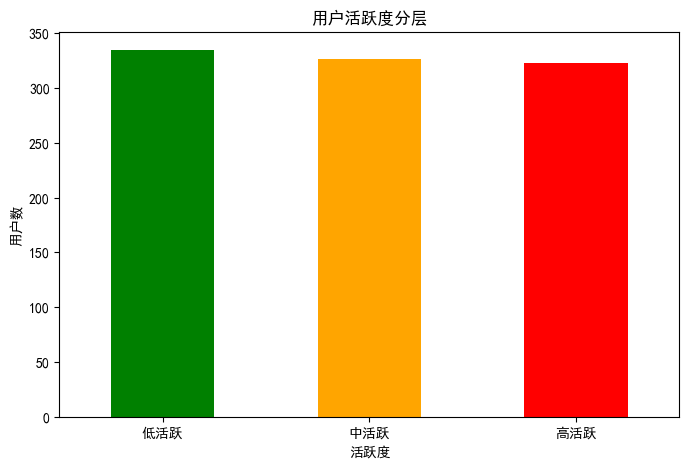

In [90]:
# 1. 用户活跃度分层（基于行为次数）
# 统计每个用户的总行为次数
user_activity = df.groupby('用户ID').size().reset_index(name='行为次数')
user_activity
print(f"用户平均行为次数: {user_activity['行为次数'].mean():.2f}")

# 定义分层阈值 
q33 = user_activity['行为次数'].quantile(0.33)
q67 = user_activity['行为次数'].quantile(0.67)

def activity_level(count):
    if count <= q33:
        return '低活跃'
    elif count <= q67:
        return '中活跃'
    else:
        return '高活跃'

user_activity['活跃度'] = user_activity['行为次数'].apply(activity_level)
# 输出结果
print("============================")
print("用户活跃度分层结果")
print(user_activity['活跃度'].value_counts())  

# 可视化活跃度分布
plt.figure(figsize=(8,5))
user_activity['活跃度'].value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title('用户活跃度分层')
plt.xlabel('活跃度')
plt.xticks(rotation=0)
plt.ylabel('用户数')
plt.show()



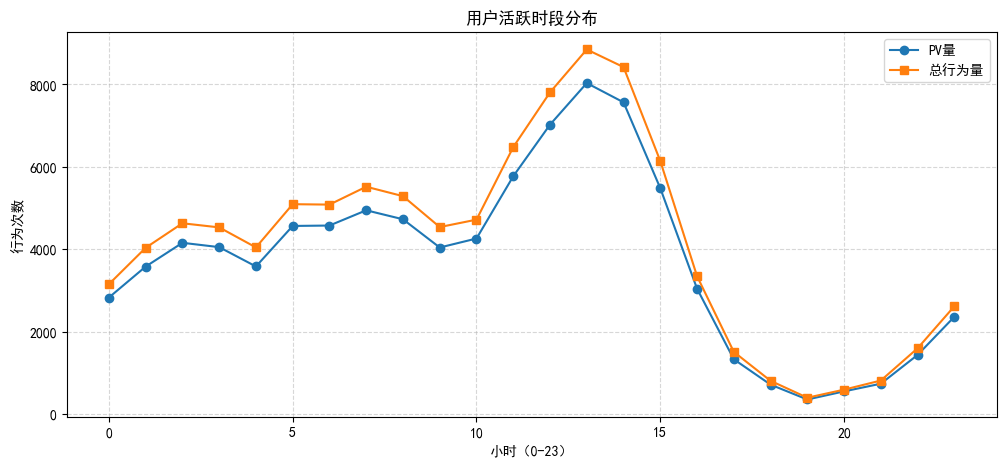

一天中最活跃的小时是: 13 点（总行为量 8847 次）


In [91]:
# 2. 时段分析：一天中哪个小时用户最活跃
# 提取小时（如果你的数据中已经有hour列，直接用）
if '小时' not in df.columns:
    df['小时'] = pd.to_datetime(df['日期']).dt.hour  # 注意：这里如果date已经是datetime，可以提取
else:
    pass

# 按小时统计所有行为次数
hourly_pv = df[df['行为类型'] == 'pv'].groupby('小时').size()
hourly_all = df.groupby('小时').size()

plt.figure(figsize=(12,5))
plt.plot(hourly_pv.index, hourly_pv.values, marker='o', label='PV量')
plt.plot(hourly_all.index, hourly_all.values, marker='s', label='总行为量')
plt.xlabel('小时（0-23）')
plt.ylabel('行为次数')
plt.title('用户活跃时段分布')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 找出最活跃的小时
peak_hour = hourly_all.idxmax()
print(f"一天中最活跃的小时是: {peak_hour} 点（总行为量 {hourly_all.max()} 次）")


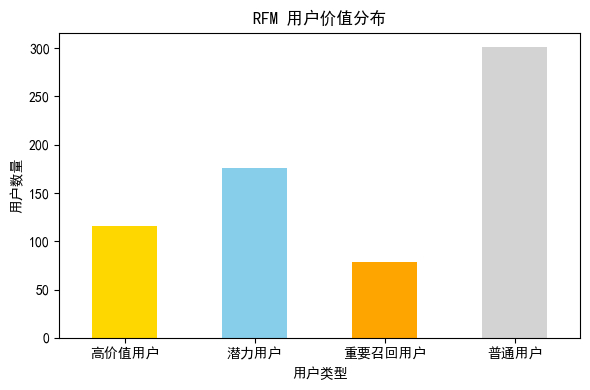

       R   F R_score F_score    用户类型
用户ID                                
100    5   8       1       3  重要召回用户
10008  1   3       3       2    潜力用户
10009  0  10       3       3   高价值用户
10020  6   1       1       1    普通用户
10021  2   1       2       1    普通用户

各类型用户数量：
用户类型
普通用户      301
潜力用户      176
高价值用户     116
重要召回用户     78
Name: count, dtype: int64


In [92]:
# 3. RFM 指标计算
# 只保留购买行为
df_buy = df[df['行为类型']=='buy'].copy()

# 计算最近购买时间
latest_date = df_buy['日期'].max()

# RFM 指标计算
rfm = df_buy.groupby('用户ID').agg({
    '日期': lambda x: (latest_date - x.max()).days,  # R：距离最近购买的天数
    '商品ID': 'count'  # F：购买次数
})
rfm.rename(columns={'日期':'R','商品ID':'F'}, inplace=True)

# R 分层（最近购买天数越少分数越高）
rfm['R_score'] = pd.qcut(rfm['R'], 3, labels=[3,2,1])

# # F 分层（购买次数越多分数越高，用 rank+qcut 避免重复分位点报错）
# rfm['F_rank'] = rfm['F'].rank(method='first')  # 排名
# rfm['F_score'] = pd.qcut(rfm['F_rank'], 3, labels=[1,2,3])

# F 分层（购买次数越多分数越高，用手动切分避免重复值问题）
f_max = rfm['F'].max()
# 根据实际分布手动分层，可以根据业务调整
bins = [0, 1, 3, f_max]  # 购买次数 0~1 → 低, 2~3 → 中, 4+ → 高
labels = [1,2,3]         # 1=低频, 2=中频, 3=高频
rfm['F_score'] = pd.cut(rfm['F'], bins=bins, labels=labels, include_lowest=True)

# 用户价值分层
def rfm_level(row):
    if row['R_score']==3 and row['F_score']==3:
        return '高价值用户'
    elif row['R_score']==3:
        return '潜力用户'
    elif row['F_score']==3:
        return '重要召回用户'
    else:
        return '普通用户'
    
rfm['用户类型'] = rfm.apply(rfm_level, axis=1)

# 可视化用户类型分布
plt.figure(figsize=(6,4))
rfm['用户类型'].value_counts().reindex(['高价值用户','潜力用户','重要召回用户','普通用户']).plot(
    kind='bar', color=['gold','skyblue','orange','lightgray']
)
plt.title("RFM 用户价值分布")
plt.xlabel("用户类型")
plt.ylabel("用户数量")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 查看分层结果
print(rfm.head())
print("\n各类型用户数量：")
print(rfm['用户类型'].value_counts())

        行为类型  用户数量   累计转化率       环节转化率
0     浏览(pv)   980  100.00  100.000000
1  意向(收藏/加购)   838   85.51   85.510204
2    购买(buy)   669   68.27   79.832936


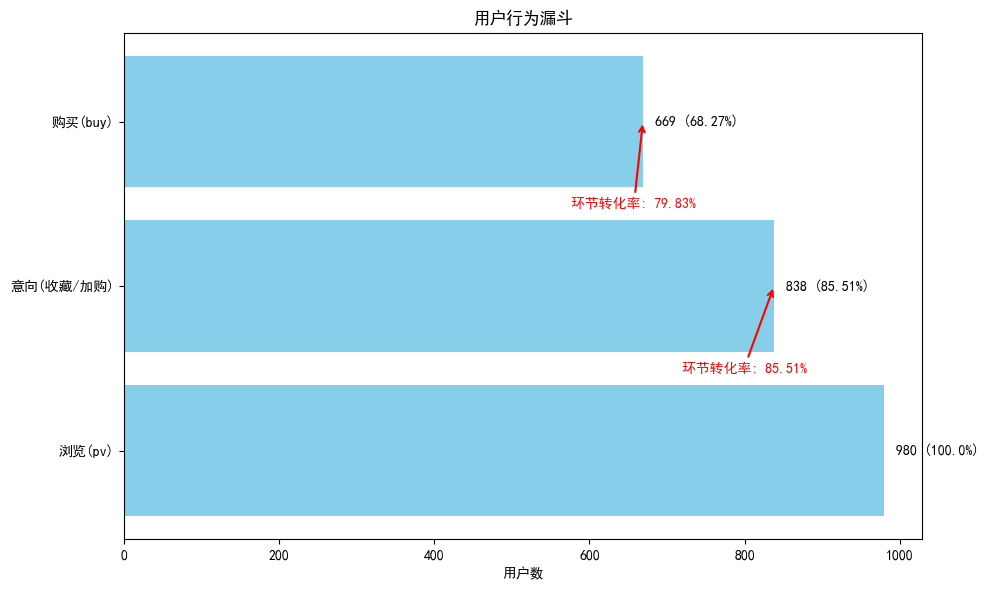

In [97]:
# 4. 用户行为漏斗分析（AARRR模型中的“激活→转化”）

# 用户集合
pv_users = set(df[df['行为类型']=='pv']['用户ID'])
fav_users = set(df[df['行为类型']=='fav']['用户ID'])
cart_users = set(df[df['行为类型']=='cart']['用户ID'])
buy_users = set(df[df['行为类型']=='buy']['用户ID'])

# 意向用户（收藏或加购且浏览过）
intent_users = (fav_users | cart_users) & pv_users

# 购买用户（购买且浏览过）
buy_users_final = buy_users & pv_users

# 漏斗数据
funnel_data = pd.DataFrame({
    '行为类型': ['浏览(pv)', '意向(收藏/加购)', '购买(buy)'],
    '用户数量': [len(pv_users), len(intent_users), len(buy_users_final)]
})

# 转化率
funnel_data['累计转化率'] = (funnel_data['用户数量']/len(pv_users)*100).round(2)
funnel_data['环节转化率'] = [
    100,
    len(intent_users)/len(pv_users)*100,
    len(buy_users_final)/len(intent_users)*100
]

print(funnel_data)

# # 绘制漏斗图
# plt.figure(figsize=(10, 6))
# plt.barh(funnel_data["行为类型"], funnel_data["用户数量"], color='skyblue')
# plt.xlabel('用户数')
# plt.title('用户行为漏斗')

# for i, v in enumerate(funnel_data['用户数量']):
#     plt.text(v + v*0.01, i, f"{v} ({funnel_data['累计转化率'][i]}%)", va='center')

# plt.tight_layout()
# plt.show()

plt.figure(figsize=(10, 6))
bars = plt.barh(funnel_data["行为类型"], funnel_data["用户数量"], color='skyblue')
plt.xlabel('用户数')
plt.title('用户行为漏斗')

# 1. 条形末端：标注用户数 + 累计转化率
for i, v in enumerate(funnel_data['用户数量']):
    plt.text(v + 15, i,  # 固定向右偏移15个单位，避免重叠
             f"{v} ({funnel_data['累计转化率'][i]}%)", 
             va='center', ha='left', fontsize=10)

# 2. 环节转化率标注（箭头+文字，位置优化）
# 浏览 → 意向
prev1 = funnel_data['用户数量'].iloc[0]
curr1 = funnel_data['用户数量'].iloc[1]
rate1 = funnel_data['环节转化率'].iloc[1]
plt.annotate(f"环节转化率: {rate1:.2f}%",
             xy=(curr1, 1),
             xytext=(prev1 - 100, 0.5),  # 文字放在两个条中间偏左
             arrowprops=dict(arrowstyle="->", color='red', lw=1.5),
             va='center', ha='right', color='red', fontweight='bold')

# 意向 → 购买
prev2 = funnel_data['用户数量'].iloc[1]
curr2 = funnel_data['用户数量'].iloc[2]
rate2 = funnel_data['环节转化率'].iloc[2]
plt.annotate(f"环节转化率: {rate2:.2f}%",
             xy=(curr2, 2),
             xytext=(prev2 - 100, 1.5),  # 文字放在两个条中间偏左
             arrowprops=dict(arrowstyle="->", color='red', lw=1.5),
             va='center', ha='right', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

In [94]:
# 收藏与加购分支对比

# 有意向（且浏览过）的用户
fav_pv = fav_users & pv_users
cart_pv = cart_users & pv_users

# 有意向且购买（且浏览过）的用户
buy_and_fav_pv = buy_users & fav_pv
buy_and_cart_pv = buy_users & cart_pv

# 计算转化率
fav_to_buy = len(buy_and_fav_pv) / len(fav_pv) * 100 if fav_pv else 0
cart_to_buy = len(buy_and_cart_pv) / len(cart_pv) * 100 if cart_pv else 0

print("===== 分支转化率对比 =====")
print(f"收藏用户数（浏览过）：{len(fav_pv)}")
print(f"收藏并购买用户数：{len(buy_and_fav_pv)}")
print(f"收藏 → 购买转化率：{fav_to_buy:.2f}%")
print("-" * 30)
print(f"加购用户数（浏览过）：{len(cart_pv)}")
print(f"加购并购买用户数：{len(buy_and_cart_pv)}")
print(f"加购 → 购买转化率：{cart_to_buy:.2f}%")

===== 分支转化率对比 =====
收藏用户数（浏览过）：361
收藏并购买用户数：266
收藏 → 购买转化率：73.68%
------------------------------
加购用户数（浏览过）：720
加购并购买用户数：525
加购 → 购买转化率：72.92%


In [95]:
# 5. 用户复购率分析
# 统计每个用户的购买次数
user_buy_counts = df[df['行为类型'] == 'buy'].groupby('用户ID').size().reset_index(name='购买次数')

rebuy_users = user_buy_counts[user_buy_counts['购买次数'] >= 2].shape[0]
total_buy_users = user_buy_counts.shape[0]

rebuy_rate = rebuy_users / total_buy_users * 100 if total_buy_users > 0 else 0
print(f"购买用户总数: {total_buy_users}")
print(f"复购用户数（购买≥2次）: {rebuy_users}")
print(f"复购率: {rebuy_rate:.2f}%")


购买用户总数: 671
复购用户数（购买≥2次）: 442
复购率: 65.87%
